In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plot_scripts as plts
plt.style.use("mplstyle")

In [2]:
dnuc = 40e-3            # MHz
nua = np.load('nua.npy')
N = len(nua)
dnu = np.arange(N)*dnuc

In [3]:
nc1 = 600

NameError: name 'cla_noflag' is not defined

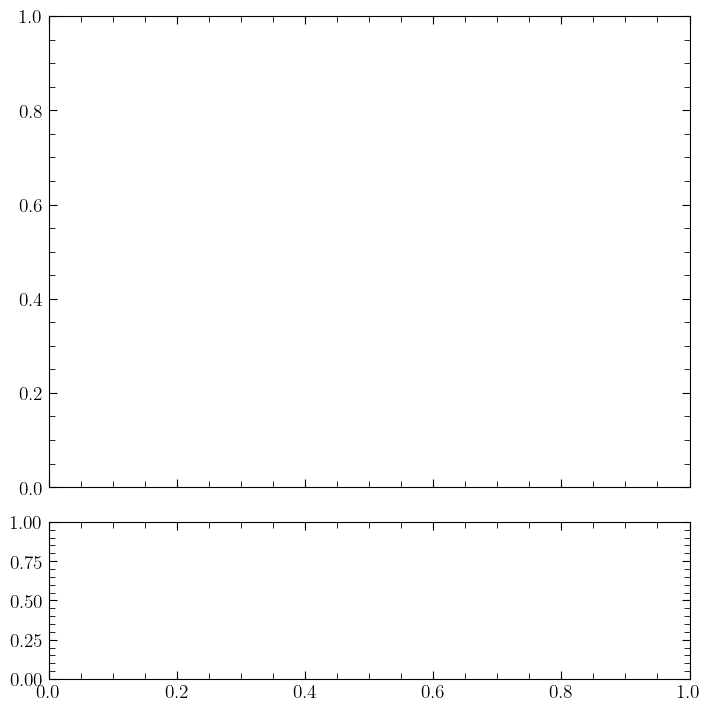

In [4]:
path = 'results'
# mode = 'NOFLAG'
# mode = 'RANDOM'
# mode = 'PERIODIC'
# mode = 'PERIODIC+RANDOM'
inp_signal = '21cm'
# inp_signal = 'FG+21cm'
inp_signal = 'FG+MM+21cm'

# SCF = 'None'
# mode = 'NOFLAG'
# data = np.load(f"{path}/CL_inp_signal-{inp_signal}_flag-{mode}_SCF-{SCF}.npz") 
# cl              = data["cl"]
# inp_signal      = data["inp_signal"].tolist()
# flag            = data["flag"].tolist()
# scf             = data["SCF"].tolist()

# Nrea = cl.shape[0]
# cla_noflag = np.average(cl, axis=0)
# cle_noflag = np.std(cl, axis=0)/np.sqrt(Nrea)

SCF = 'Hann'
# mode = 'NOFLAG'
mode = 'PERIODIC'
mode = 'PERIODIC+RANDOM'
mode = 'RANDOM'

data = np.load(f"{path}/CL_inp_signal-{inp_signal}_flag-{mode}_SCF-{SCF}.npz") 
cl              = data["cl"]
inp_signal      = data["inp_signal"].tolist()
flag            = data["flag"].tolist()
scf             = data["SCF"].tolist()

Nrea = cl.shape[0]
cla_periodic = np.average(cl, axis=0)
cle_periodic = np.std(cl, axis=0)/np.sqrt(Nrea)


SCF = 'GP'
data = np.load(f"{path}/CL_inp_signal-{inp_signal}_flag-{mode}_SCF-{SCF}.npz") 
cl1              = data["cl"]
inp_signal1      = data["inp_signal"].tolist()
flag1            = data["flag"].tolist()
scf1             = data["SCF"].tolist()


fig, axes = plt.subplots(
    2, 1,
    figsize=(7, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

ax  = axes[0]
axd = axes[1]

# ============================
# Top panel: C(Δν)
# ============================
ax.plot(
    dnu[:nc1], cla_noflag[:nc1],
    color='k', lw=2, label='NO FLAG'
)
ax.fill_between(
    dnu[:nc1],
    cla_noflag[:nc1] - cle_noflag[:nc1],
    cla_noflag[:nc1] + cle_noflag[:nc1],
    color='k', alpha=0.25
)

ax.plot(
    dnu[:nc1], cla_periodic[:nc1],
    color='r', lw=2, label='PERIODIC'
)
ax.fill_between(
    dnu[:nc1],
    cla_periodic[:nc1] - cle_periodic[:nc1],
    cla_periodic[:nc1] + cle_periodic[:nc1],
    color='r', alpha=0.25
)

ax.set_ylabel(r'$C(\Delta\nu)$')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

# ============================
# Bottom panel: Difference
# ============================
cl_diff  = cla_periodic[:nc1] - cla_noflag[:nc1]
cle_diff = np.sqrt(cle_periodic[:nc1]**2 + 0*cle_noflag[:nc1]**2)

axd.axhline(0.0, color='gray', ls='--', lw=1)
axd.plot(
    dnu[:nc1], cl_diff,
    color='b', lw=2
)
axd.fill_between(
    dnu[:nc1],
    cl_diff - cle_diff,
    cl_diff + cle_diff,
    color='b', alpha=0.3
)

axd.set_xlabel(r'$\Delta\nu\ {\rm [MHz]}$')
axd.set_ylabel(r'$\Delta C$')
axd.grid(alpha=0.3)

plt.tight_layout()
plt.show()







In [ ]:
plt.figure(figsize=(7, 4))

plt.plot(dnu[:nc1], cla_noflag[:nc1], color='k', lw=2, label='NO FLAG')
plt.fill_between(
    dnu[:nc1],
    cla_noflag[:nc1] - cle_noflag[:nc1],
    cla_noflag[:nc1] + cle_noflag[:nc1],
    color='k', alpha=0.25
)

plt.plot(dnu[:nc1], cla_periodic[:nc1], color='r', lw=2, label='PERIODIC')
plt.fill_between(
    dnu[:nc1],
    cla_periodic[:nc1] - cle_periodic[:nc1],
    cla_periodic[:nc1] + cle_periodic[:nc1],
    color='r', alpha=0.25
)

plt.xlabel(r'$\Delta\nu\ {\rm [MHz]}$')
plt.ylabel(r'$C(\Delta\nu)$')
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

cl_diff  = cla_periodic[:nc1] - cla_noflag[:nc1]
cle_diff = np.sqrt(cle_periodic[:nc1]**2 + 0*cle_noflag[:nc1]**2)

plt.figure(figsize=(7, 3))

plt.axhline(0.0, color='gray', ls='--', lw=1)
plt.plot(dnu[:nc1], cl_diff[:nc1], color='b', lw=2)
plt.fill_between(
    dnu[:nc1],
    cl_diff[:nc1] - cle_diff[:nc1],
    cl_diff[:nc1] + cle_diff[:nc1],
    color='b', alpha=0.3
)

plt.xlabel(r'$\Delta\nu\ {\rm [MHz]}$')
plt.ylabel(r'$\Delta C$')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



In [ ]:
cla_noflag.shape, 
nc1 = 640 # len(cla_periodic)

In [ ]:
cla_noflag.shape, cla_periodic.shape

In [ ]:
nnm = 100
plt.plot(dnu[:nnm], cla_noflag[:nnm])
plt.plot(dnu[:nnm], cla_periodic[:nnm])



In [ ]:
plt.plot(dnu[:nc1], cla_noflag[:nc1])
plt.plot(dnu[:nc1], cla_periodic[:nc1])
plt.show()


In [ ]:
plt.plot(dnu[:nc1], cla_noflag[:nc1])
plt.plot(dnu[:nc1], cla_periodic[:nc1])
# plt.plot(dnu[:nc1], cla_periodic)
plt.show()


In [ ]:
plt.plot(dnu[:nc1], cla_noflag[:nc1]-cla_periodic[:nc1])


In [ ]:
%%